In [182]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

for n_comp in [0.95, 0.98, 0.99]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_comp)),
        ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
    ])

    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    pca = model.named_steps["pca"]

    print(
        f"PCA={n_comp} | "
        f"Componentes={pca.n_components_} | "
        f"Variância={sum(pca.explained_variance_ratio_):.4f} | "
        f"Acc={acc:.4f}"
    )

PCA=0.95 | Componentes=147 | Variância=0.9503 | Acc=0.9222
PCA=0.98 | Componentes=192 | Variância=0.9801 | Acc=0.9222
PCA=0.99 | Componentes=222 | Variância=0.9902 | Acc=0.9222


Features: 244 MFCC+esp | 48 chroma | 4 onset | 64 LSTM
Total: 360 | Treino: 1335 | Teste: 334

Treinando SVM com GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Melhores parâmetros SVM: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Acurácia SVM           : 0.9192

Treinando MLP com GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Melhores parâmetros MLP: {'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': (256, 128, 64), 'classifier__learning_rate_init': 0.001}
Acurácia MLP           : 0.9192

RESULTADO FINAL
SVM : 0.9192
MLP : 0.9192

Modelo escolhido: SVM

Relatório detalhado:
              precision    recall  f1-score   support

     direita       0.98      0.90      0.94        67
    esquerda       0.83      0.88      0.86        67
        pare       0.89      0.98      0.94        66
        siga       0.91      0.87      0.89        67
      voltar       1.00      0.97      

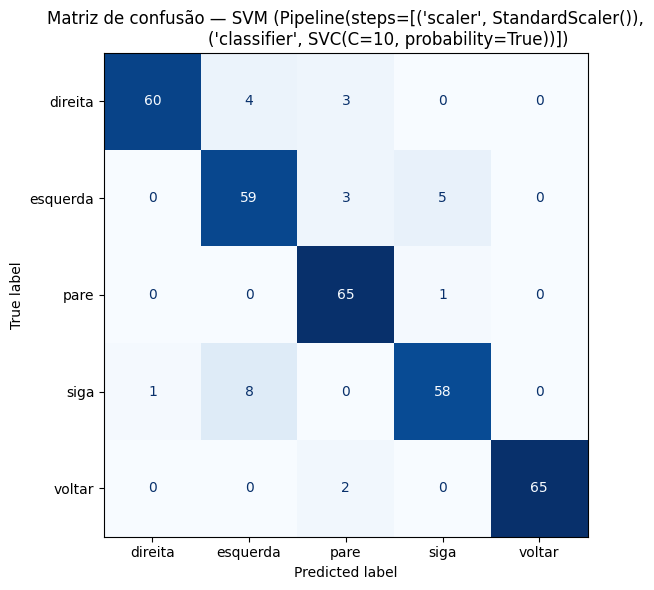

Matriz salva em: matriz_confusao_final.png

Modelo salvo: modelo_final.pkl
Label encoder salvo: label_encoder_final.pkl


In [183]:
"""
PASSO 3 — Treina e compara SVM vs MLP com as features completas.
Substitui seu script de treino anterior.

Execute: python 3_treinar_modelo_final.py
Gera:    modelo_final.pkl  e  label_encoder_final.pkl
"""

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.neural_network  import MLPClassifier
from sklearn.svm             import SVC
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (accuracy_score, classification_report,
                                     confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt


# ========================
# 1. CARREGAR DADOS
# ========================

df = pd.read_csv("features_audio_final.csv")

X = df.drop(["label", "arquivo"], axis=1)
y = df["label"]

le        = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

n_f      = len([c for c in X.columns if c.startswith("f_")])
n_chroma = len([c for c in X.columns if c.startswith("chroma_")])
n_onset  = len([c for c in X.columns if c.startswith("onset_")])
n_lstm   = len([c for c in X.columns if c.startswith("lstm_")])
print(f"Features: {n_f} MFCC+esp | {n_chroma} chroma | {n_onset} onset | {n_lstm} LSTM")
print(f"Total: {len(X.columns)} | Treino: {len(X_train)} | Teste: {len(X_test)}\n")


# ========================
# 2. SVM (busca de hiperparâmetros)
# ========================

print("=" * 50)
print("Treinando SVM com GridSearchCV...")
print("=" * 50)

svm_pipeline = Pipeline([
    ("scaler",     StandardScaler()),
    ("classifier", SVC(probability=True))
])

svm_params = {
    "classifier__C":     [1, 10, 100],
    "classifier__gamma": ["scale", "auto"],
    "classifier__kernel": ["rbf", "poly"],
}

svm_gs = GridSearchCV(
    svm_pipeline, svm_params,
    cv=5, scoring="accuracy",
    n_jobs=1, verbose=1
)
svm_gs.fit(X_train, y_train)

svm_best  = svm_gs.best_estimator_
svm_pred  = svm_best.predict(X_test)
svm_acc   = accuracy_score(y_test, svm_pred)

print(f"\nMelhores parâmetros SVM: {svm_gs.best_params_}")
print(f"Acurácia SVM           : {svm_acc:.4f}")


# ========================
# 3. MLP (busca de hiperparâmetros)
# ========================

print("\n" + "=" * 50)
print("Treinando MLP com GridSearchCV...")
print("=" * 50)

mlp_pipeline = Pipeline([
    ("scaler",     StandardScaler()),
    ("classifier", MLPClassifier(
        activation="relu",
        solver="adam",
        early_stopping=True,
        validation_fraction=0.1,
        max_iter=500,
        random_state=42
    ))
])

mlp_params = {
    "classifier__hidden_layer_sizes": [
        (128, 64),
        (256, 128),
        (256, 128, 64),
    ],
    "classifier__alpha":              [0.0001, 0.001, 0.01],
    "classifier__learning_rate_init": [0.001, 0.0005],
}

mlp_gs = GridSearchCV(
    mlp_pipeline, mlp_params,
    cv=5, scoring="accuracy",
    n_jobs=1, verbose=1
)
mlp_gs.fit(X_train, y_train)

mlp_best = mlp_gs.best_estimator_
mlp_pred = mlp_best.predict(X_test)
mlp_acc  = accuracy_score(y_test, mlp_pred)

print(f"\nMelhores parâmetros MLP: {mlp_gs.best_params_}")
print(f"Acurácia MLP           : {mlp_acc:.4f}")


# ========================
# 4. COMPARAÇÃO FINAL
# ========================

print("\n" + "=" * 50)
print("RESULTADO FINAL")
print("=" * 50)
print(f"SVM : {svm_acc:.4f}")
print(f"MLP : {mlp_acc:.4f}")

# Escolhe o melhor automaticamente
if svm_acc >= mlp_acc:
    melhor_modelo = svm_best
    melhor_pred   = svm_pred
    nome_melhor   = "SVM"
else:
    melhor_modelo = mlp_best
    melhor_pred   = mlp_pred
    nome_melhor   = "MLP"

print(f"\nModelo escolhido: {nome_melhor}")

print("\nRelatório detalhado:")
print(classification_report(y_test, melhor_pred, target_names=le.classes_))

# ========================
# 5. MATRIZ DE CONFUSÃO
# ========================

cm  = confusion_matrix(y_test, melhor_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de confusão — {nome_melhor} ({melhor_modelo}")
plt.tight_layout()
plt.savefig("matriz_confusao_final.png", dpi=150)
plt.show()
print("Matriz salva em: matriz_confusao_final.png")

# ========================
# 6. SALVA MODELO
# ========================

joblib.dump(melhor_modelo, "modelo_final.pkl")
joblib.dump(le,            "label_encoder_final.pkl")

print(f"\nModelo salvo: modelo_final.pkl")
print(f"Label encoder salvo: label_encoder_final.pkl")

In [184]:
print("\nRelatório detalhado:")
print(classification_report(y_test, melhor_pred, target_names=le.classes_))


Relatório detalhado:
              precision    recall  f1-score   support

     direita       0.98      0.90      0.94        67
    esquerda       0.83      0.88      0.86        67
        pare       0.89      0.98      0.94        66
        siga       0.91      0.87      0.89        67
      voltar       1.00      0.97      0.98        67

    accuracy                           0.92       334
   macro avg       0.92      0.92      0.92       334
weighted avg       0.92      0.92      0.92       334

